<a href="https://colab.research.google.com/github/fralfaro/MA_M3/blob/main/semana_03/vis_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tipos de Gráficos

## Introducción

<img src="https://datatab.net/assets/tutorial/Diagram_Types.png" align="center" width = "650">


En estadística, un gráfico es una representación visual de datos que permite resumir, analizar
y comunicar información de manera efectiva. Esta clase cubre tipos fundamentales de gráficos
usando **matplotlib** como herramienta principal.

El objetivo es practicar la API orientada a objetos (`fig, ax = plt.subplots()`), porque entrega
más control sobre títulos, ejes, leyendas, anotaciones, colores y composición de figuras.


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducibilidad
rng = np.random.default_rng(42)

# Estilo general con matplotlib
plt.style.use("bmh")
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

# Datos de ejemplo: cuentas y propinas simuladas
n = 244
dias = ["Jue", "Vie", "Sab", "Dom"]
sexos = ["Femenino", "Masculino"]
propinas = pd.DataFrame({
    "dia": rng.choice(dias, size=n, p=[0.25, 0.18, 0.36, 0.21]),
    "sexo": rng.choice(sexos, size=n, p=[0.45, 0.55]),
    "tamano_mesa": rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.42, 0.22, 0.21, 0.06, 0.04]),
})
propinas["cuenta_total"] = np.round(
    rng.gamma(shape=4.2, scale=5.0, size=n)
    + propinas["tamano_mesa"] * 2.1
    + propinas["dia"].map({"Jue": 0, "Vie": 2, "Sab": 5, "Dom": 3}).to_numpy(),
    2,
)
propinas["propina"] = np.round(
    propinas["cuenta_total"] * rng.normal(0.16, 0.035, size=n)
    + rng.normal(0, 0.8, size=n),
    2,
).clip(lower=0.5)

# Datos de ejemplo: flores simuladas para dispersión y correlación
especies = ["setosa", "versicolor", "virginica"]
params = {
    "setosa": ((5.0, 3.4, 1.5, 0.25), (0.35, 0.25, 0.18, 0.08)),
    "versicolor": ((5.9, 2.8, 4.2, 1.3), (0.45, 0.25, 0.35, 0.18)),
    "virginica": ((6.6, 3.0, 5.5, 2.0), (0.55, 0.30, 0.45, 0.22)),
}
iris = []
for especie in especies:
    medias, desvios = params[especie]
    datos = rng.normal(medias, desvios, size=(50, 4))
    tmp = pd.DataFrame(datos, columns=["sepalo_largo", "sepalo_ancho", "petalo_largo", "petalo_ancho"])
    tmp["especie"] = especie
    iris.append(tmp)
iris = pd.concat(iris, ignore_index=True)


def kde_gaussiana(valores, puntos=200, ancho_banda=None):
    """Estimación KDE simple con NumPy para evitar dependencias extra."""
    valores = np.asarray(valores, dtype=float)
    xs = np.linspace(valores.min(), valores.max(), puntos)
    if ancho_banda is None:
        ancho_banda = 1.06 * valores.std(ddof=1) * len(valores) ** (-1 / 5)
    z = (xs[:, None] - valores[None, :]) / ancho_banda
    densidad = np.exp(-0.5 * z**2).sum(axis=1) / (len(valores) * ancho_banda * np.sqrt(2 * np.pi))
    return xs, densidad


## Anatomía de un Gráfico

Antes de graficar, conviene conocer los componentes que matplotlib expone:

![Anatomía matplotlib](https://matplotlib.org/stable/_images/anatomy.png)

| Componente | Descripción |
|---|---|
| **Figure** | Contenedor principal; puede tener uno o varios ejes. |
| **Axes** | El área de dibujo con sus ejes x e y. |
| **Title** | Texto descriptivo en la parte superior. |
| **Axis Labels** | Etiquetas de cada eje (xlabel, ylabel). |
| **Legend** | Caja que explica el significado de cada serie. |
| **Ticks / Grid** | Marcas y cuadrícula para facilitar la lectura. |

```python
fig, ax = plt.subplots()
ax.set_title("Título del gráfico")
ax.set_xlabel("Eje x")
ax.set_ylabel("Eje y")
```


## Gráfico de Línea

**Cuándo:** evolución de una variable numérica a lo largo de un eje ordenado —
típicamente el tiempo. El orden de los puntos importa.

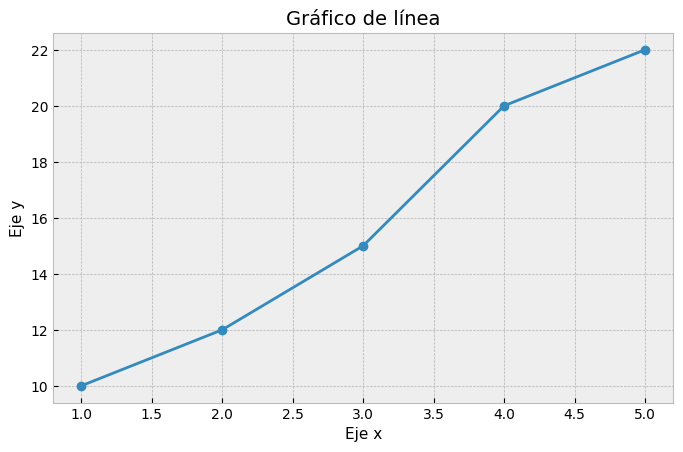

In [29]:
# Básico — matplotlib
x = [1, 2, 3, 4, 5]
y = [10, 12, 15, 20, 22]

plt.plot(x, y, marker="o")
plt.xlabel("Eje x")
plt.ylabel("Eje y")
plt.title("Gráfico de línea")
plt.show()

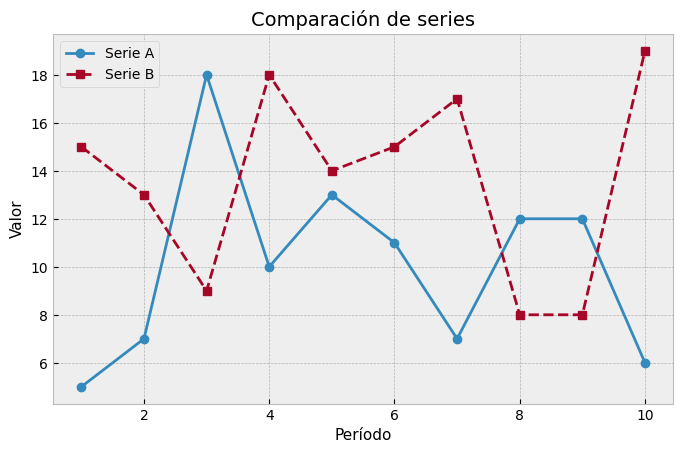

In [30]:
# Múltiples series — matplotlib
x = np.arange(1, 11)
y1 = np.random.randint(5, 20, size=10)
y2 = np.random.randint(5, 20, size=10)

fig, ax = plt.subplots()
ax.plot(x, y1, marker="o", label="Serie A")
ax.plot(x, y2, marker="s", linestyle="--", label="Serie B")
ax.set_xlabel("Período")
ax.set_ylabel("Valor")
ax.set_title("Comparación de series")
ax.legend()
plt.show()

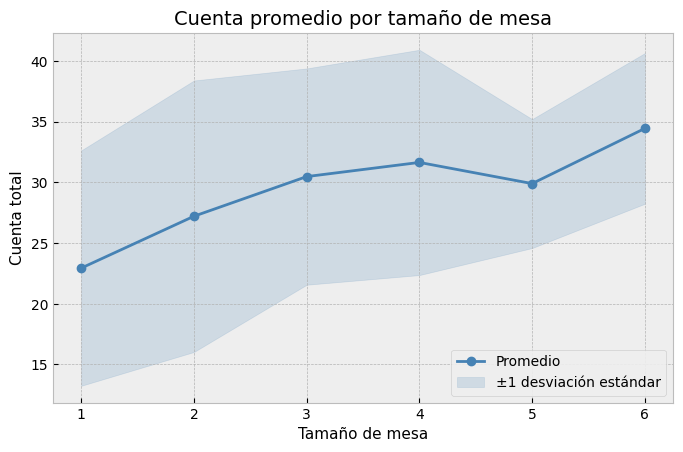

In [31]:
# Con banda de variabilidad — matplotlib
resumen = (
    propinas
    .groupby("tamano_mesa", as_index=False)["cuenta_total"]
    .agg(media="mean", sd="std")
)

fig, ax = plt.subplots()
ax.plot(resumen["tamano_mesa"], resumen["media"], marker="o", color="steelblue", label="Promedio")
ax.fill_between(
    resumen["tamano_mesa"],
    resumen["media"] - resumen["sd"],
    resumen["media"] + resumen["sd"],
    color="steelblue",
    alpha=0.18,
    label="±1 desviación estándar",
)
ax.set_xlabel("Tamaño de mesa")
ax.set_ylabel("Cuenta total")
ax.set_title("Cuenta promedio por tamaño de mesa")
ax.legend()
plt.show()


> La banda se construye manualmente con `ax.fill_between()`, usando el promedio y ±1 desviación estándar por grupo.


## Gráfico de Dispersión

**Cuándo:** explorar la relación entre dos variables numéricas continuas.
Detecta correlaciones, outliers y clusters.

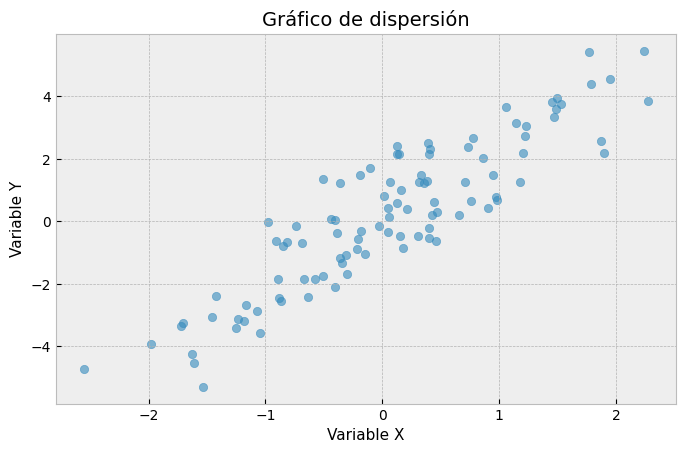

In [32]:
# Básico — matplotlib
np.random.seed(0)
x = np.random.randn(100)
y = 2 * x + np.random.randn(100)

plt.scatter(x, y, alpha=0.6)
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.title("Gráfico de dispersión")
plt.show()

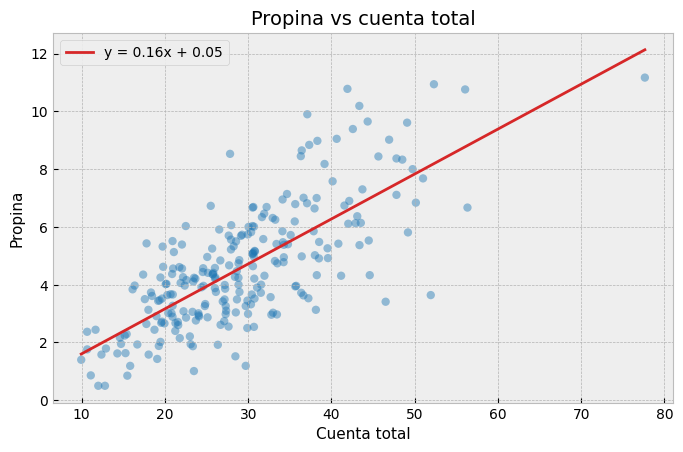

In [33]:
# Con recta de regresión — matplotlib
x = propinas["cuenta_total"].to_numpy()
y = propinas["propina"].to_numpy()
pendiente, intercepto = np.polyfit(x, y, deg=1)
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = pendiente * x_linea + intercepto

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.45, color="tab:blue", edgecolor="none")
ax.plot(x_linea, y_linea, color="tab:red", linewidth=2, label=f"y = {pendiente:.2f}x + {intercepto:.2f}")
ax.set_xlabel("Cuenta total")
ax.set_ylabel("Propina")
ax.set_title("Propina vs cuenta total")
ax.legend()
plt.show()


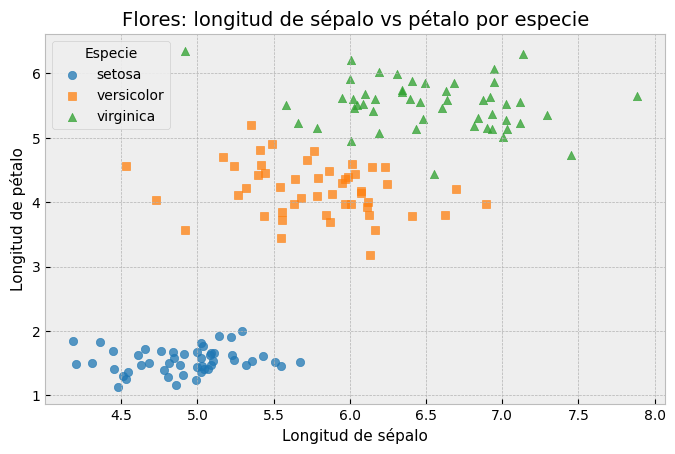

In [34]:
# Coloreado por categoría — matplotlib
colores = {"setosa": "tab:blue", "versicolor": "tab:orange", "virginica": "tab:green"}
marcadores = {"setosa": "o", "versicolor": "s", "virginica": "^"}

fig, ax = plt.subplots()
for especie, grupo in iris.groupby("especie"):
    ax.scatter(
        grupo["sepalo_largo"],
        grupo["petalo_largo"],
        label=especie,
        color=colores[especie],
        marker=marcadores[especie],
        alpha=0.75,
    )
ax.set_xlabel("Longitud de sépalo")
ax.set_ylabel("Longitud de pétalo")
ax.set_title("Flores: longitud de sépalo vs pétalo por especie")
ax.legend(title="Especie")
plt.show()


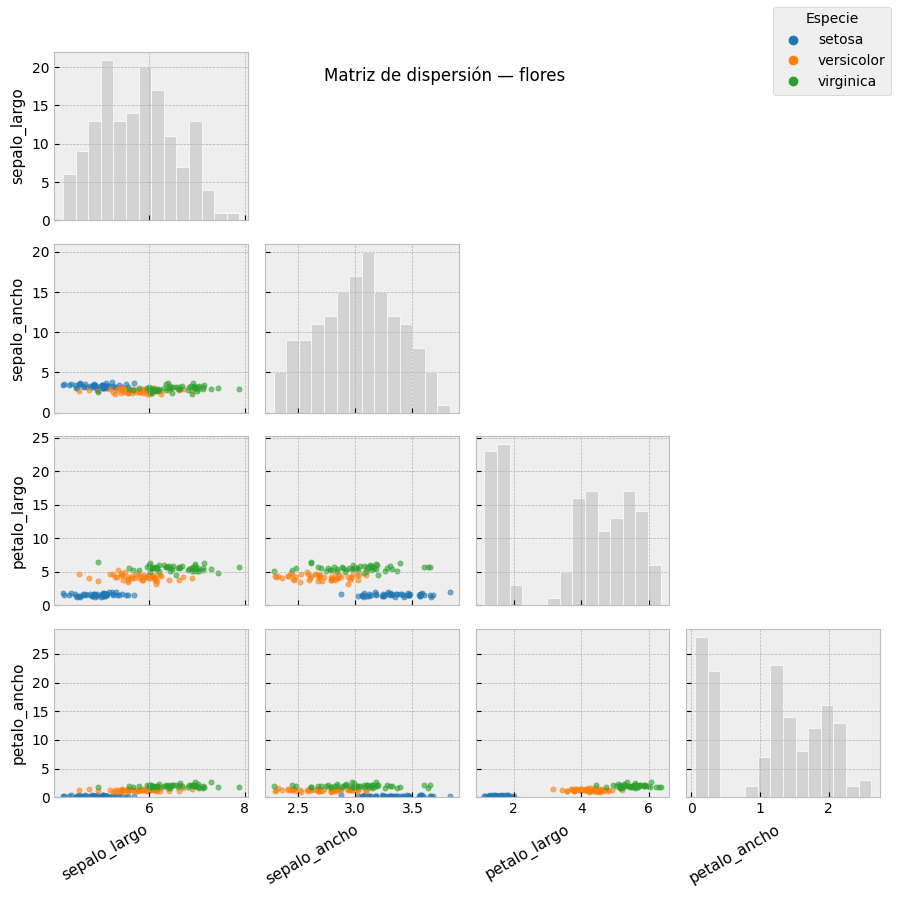

In [35]:
# Matriz de dispersión — matplotlib
variables = ["sepalo_largo", "sepalo_ancho", "petalo_largo", "petalo_ancho"]
fig, axes = plt.subplots(len(variables), len(variables), figsize=(9, 9), sharex="col", sharey="row")

for i, var_y in enumerate(variables):
    for j, var_x in enumerate(variables):
        ax = axes[i, j]
        if i == j:
            ax.hist(iris[var_x], bins=14, color="lightgray", edgecolor="white")
        elif i > j:
            for especie, grupo in iris.groupby("especie"):
                ax.scatter(grupo[var_x], grupo[var_y], s=14, alpha=0.6, color=colores[especie])
        else:
            ax.axis("off")
        if i == len(variables) - 1:
            ax.set_xlabel(var_x, rotation=30, ha="right")
        if j == 0:
            ax.set_ylabel(var_y)

handles = [plt.Line2D([], [], marker="o", linestyle="", color=colores[e], label=e) for e in especies]
fig.legend(handles=handles, title="Especie", loc="upper right")
fig.suptitle("Matriz de dispersión — flores", y=0.93)
plt.tight_layout()
plt.show()


##  Gráfico de Barras

**Cuándo:** comparar magnitudes entre categorías discretas sin orden intrínseco.
Lo que importa es la altura relativa de cada barra, no la tendencia entre ellas.


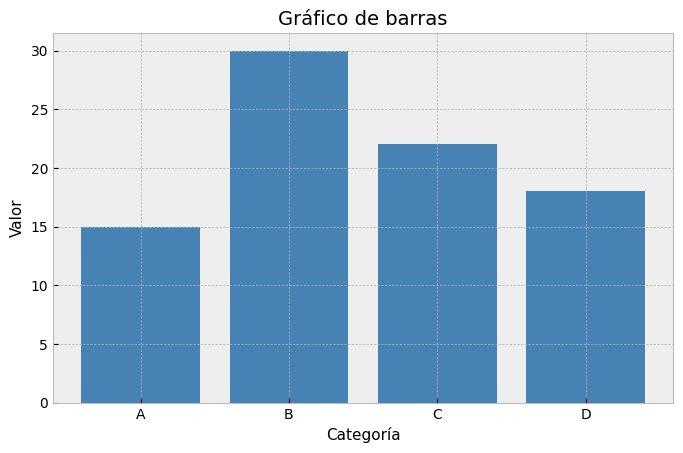

In [36]:
# Básico — matplotlib
categorias = ["A", "B", "C", "D"]
valores = [15, 30, 22, 18]

plt.bar(categorias, valores, color="steelblue")
plt.xlabel("Categoría")
plt.ylabel("Valor")
plt.title("Gráfico de barras")
plt.show()

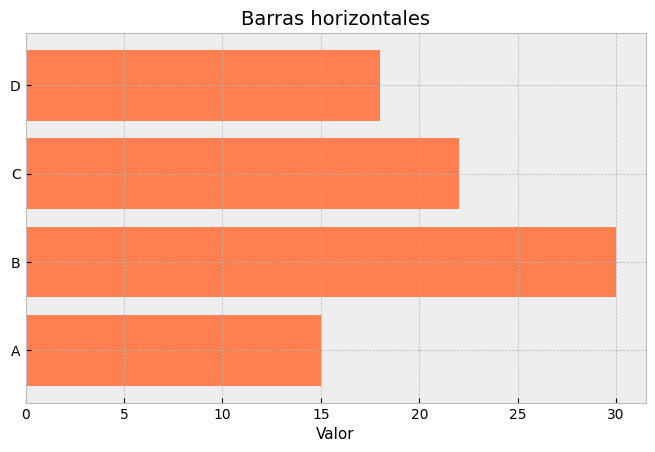

In [37]:
# Horizontal — matplotlib
plt.barh(categorias, valores, color="coral")
plt.xlabel("Valor")
plt.title("Barras horizontales")
plt.show()

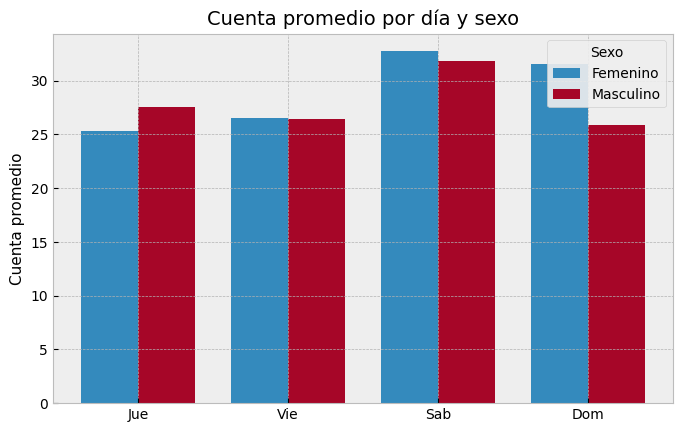

In [38]:
# Barras agrupadas — matplotlib
tabla = propinas.pivot_table(index="dia", columns="sexo", values="cuenta_total", aggfunc="mean").reindex(dias)

x = np.arange(len(tabla.index))
ancho = 0.38
fig, ax = plt.subplots()
for k, sexo in enumerate(tabla.columns):
    offset = (k - 0.5) * ancho
    ax.bar(x + offset, tabla[sexo], width=ancho, label=sexo)

ax.set_xticks(x)
ax.set_xticklabels(tabla.index)
ax.set_ylabel("Cuenta promedio")
ax.set_title("Cuenta promedio por día y sexo")
ax.legend(title="Sexo")
plt.show()


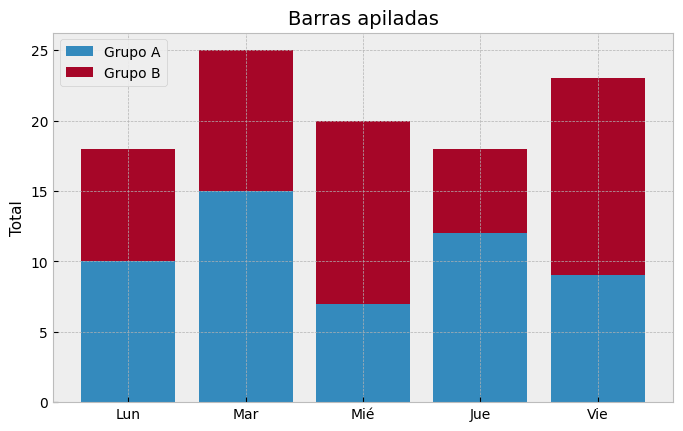

In [39]:
# Apiladas — matplotlib
dias = ["Lun", "Mar", "Mié", "Jue", "Vie"]
grupo_a = [10, 15, 7, 12, 9]
grupo_b = [8, 10, 13, 6, 14]

x = np.arange(len(dias))
plt.bar(x, grupo_a, label="Grupo A")
plt.bar(x, grupo_b, bottom=grupo_a, label="Grupo B")
plt.xticks(x, dias)
plt.ylabel("Total")
plt.title("Barras apiladas")
plt.legend()
plt.show()

## Gráfico: Histograma

**Cuándo:** visualizar la distribución de una variable numérica continua.
El eje x se divide en intervalos (bins); el eje y muestra la frecuencia o densidad.

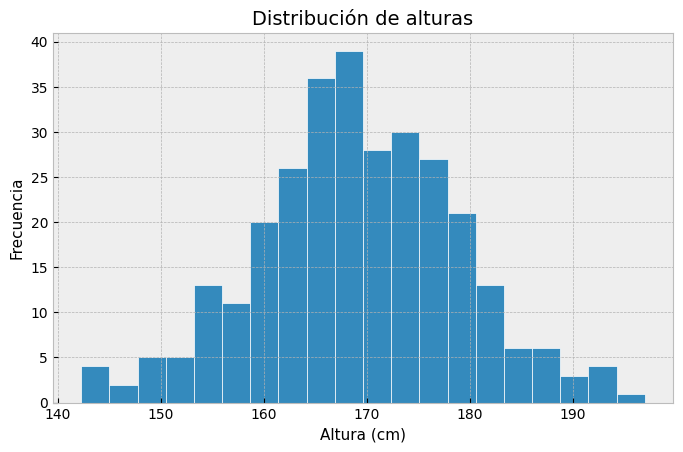

In [40]:
# Básico — matplotlib
datos = np.random.normal(loc=170, scale=10, size=300)

plt.hist(datos, bins=20, edgecolor="white")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.title("Distribución de alturas")
plt.show()

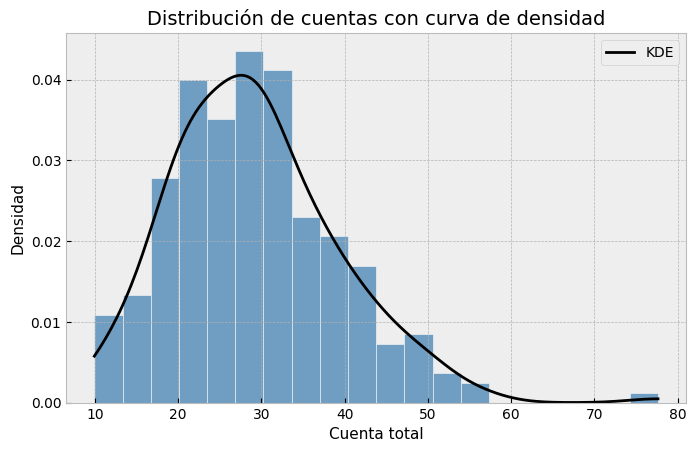

In [41]:
# Histograma con curva de densidad — matplotlib
valores = propinas["cuenta_total"]
xs, densidad = kde_gaussiana(valores)

fig, ax1 = plt.subplots()
ax1.hist(valores, bins=20, color="steelblue", alpha=0.75, edgecolor="white", density=True)
ax1.plot(xs, densidad, color="black", linewidth=2, label="KDE")
ax1.set_xlabel("Cuenta total")
ax1.set_ylabel("Densidad")
ax1.set_title("Distribución de cuentas con curva de densidad")
ax1.legend()
plt.show()


> La curva de densidad se calcula con una KDE gaussiana simple y se superpone con `ax.plot()`.


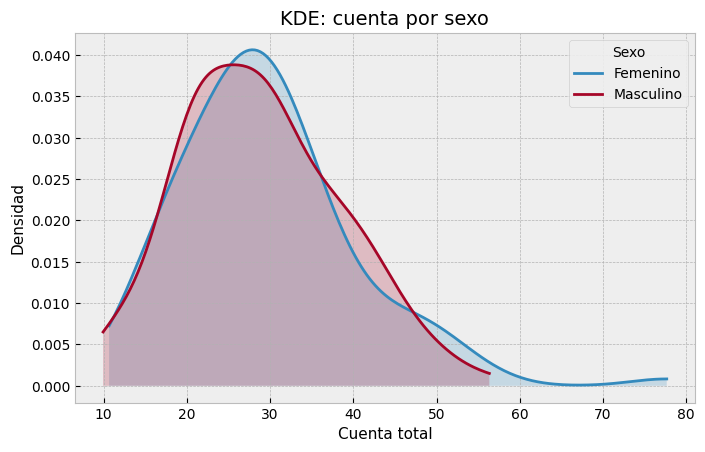

In [42]:
# Comparar distribuciones — matplotlib
fig, ax = plt.subplots()
for sexo, grupo in propinas.groupby("sexo"):
    xs, densidad = kde_gaussiana(grupo["cuenta_total"])
    ax.plot(xs, densidad, linewidth=2, label=sexo)
    ax.fill_between(xs, densidad, alpha=0.22)

ax.set_xlabel("Cuenta total")
ax.set_ylabel("Densidad")
ax.set_title("KDE: cuenta por sexo")
ax.legend(title="Sexo")
plt.show()


## Gráfico: Heatmap

**Cuándo:** representar una matriz de valores numéricos usando color como codificación.
Ideal para matrices de correlación, tablas de contingencia o datos tabulares densos.

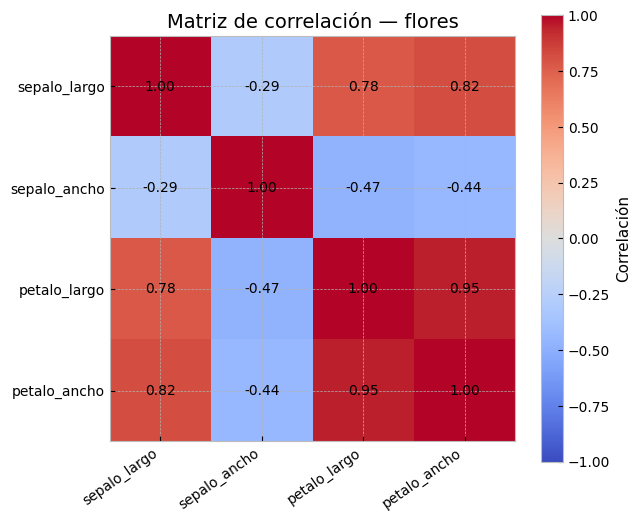

In [43]:
# Matriz de correlación — matplotlib
corr = iris.drop(columns="especie").corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Correlación")
ax.set_title("Matriz de correlación — flores")
plt.tight_layout()
plt.show()


> Los valores se agregan con `ax.text()` y la escala de color se fija con `vmin=-1` y `vmax=1`.


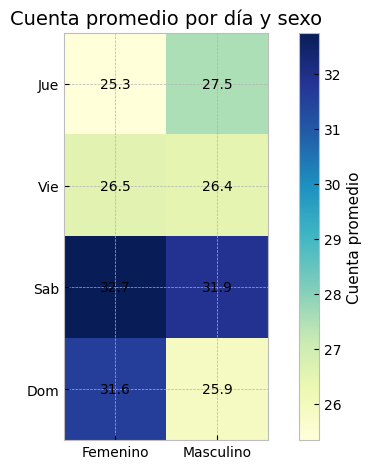

In [49]:
# Tabla de contingencia — matplotlib
dias = ["Jue", "Vie", "Sab", "Dom"]
tabla = propinas.pivot_table(index="dia", columns="sexo", values="cuenta_total", aggfunc="mean").reindex(dias)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
im = ax.imshow(tabla, cmap="YlGnBu")
ax.set_xticks(range(len(tabla.columns)))
ax.set_yticks(range(len(tabla.index)))
ax.set_xticklabels(tabla.columns)
ax.set_yticklabels(tabla.index)

for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, f"{tabla.iloc[i, j]:.1f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Cuenta promedio")
ax.set_title("Cuenta promedio por día y sexo")
plt.tight_layout()
plt.show()


## Gráfico: Boxplot

**Cuándo:** comparar la distribución de una variable numérica entre grupos.
Muestra mediana, cuartiles y outliers en una sola figura.


<img src="https://miro.medium.com/v2/resize:fit:9000/1*2c21SkzJMf3frPXPAR_gZA.png" align="center" width = "520">


/tmp/ipykernel_2806/2386589001.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["Grupo A", "Grupo B", "Grupo C"])


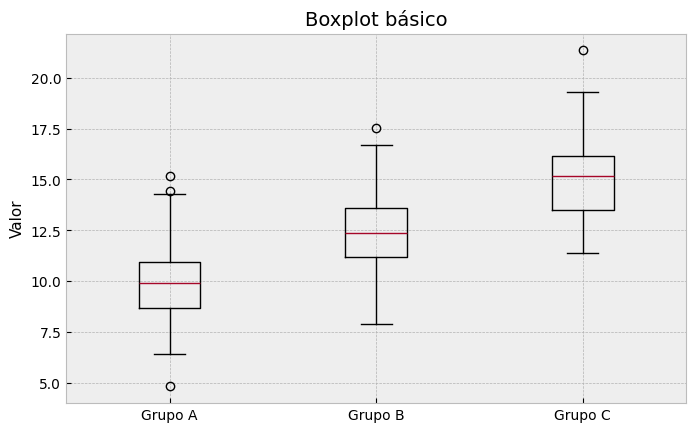

In [50]:
# Básico — matplotlib
datos = [np.random.normal(loc, 2, 100) for loc in [10, 12, 15]]

plt.boxplot(datos, labels=["Grupo A", "Grupo B", "Grupo C"])
plt.ylabel("Valor")
plt.title("Boxplot básico")
plt.show()

In [51]:
dias

['Jue', 'Vie', 'Sab', 'Dom']

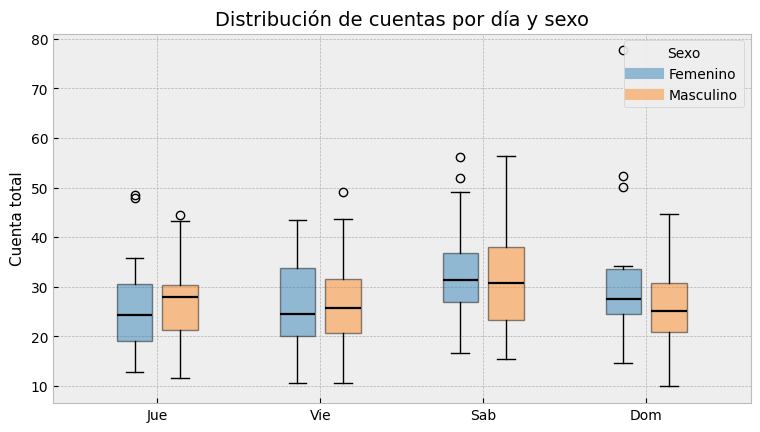

In [52]:
# Boxplot por categoría — matplotlib
fig, ax = plt.subplots(figsize=(9, 4.8))
posiciones = []
datos_box = []
colores_box = []

for i, dia in enumerate(dias):
    for j, sexo in enumerate(sexos):
        posiciones.append(i + (j - 0.5) * 0.28)
        datos_box.append(propinas.loc[(propinas["dia"] == dia) & (propinas["sexo"] == sexo), "cuenta_total"])
        colores_box.append("tab:blue" if sexo == "Femenino" else "tab:orange")

bp = ax.boxplot(datos_box, positions=posiciones, widths=0.22, patch_artist=True, showfliers=True)
for caja, color in zip(bp["boxes"], colores_box):
    caja.set_facecolor(color)
    caja.set_alpha(0.45)
for mediana in bp["medians"]:
    mediana.set_color("black")
    mediana.set_linewidth(1.6)

ax.set_xticks(range(len(dias)))
ax.set_xticklabels(dias)
ax.set_ylabel("Cuenta total")
ax.set_title("Distribución de cuentas por día y sexo")
handles = [plt.Line2D([], [], color="tab:blue", lw=8, alpha=0.45, label="Femenino"),
           plt.Line2D([], [], color="tab:orange", lw=8, alpha=0.45, label="Masculino")]
ax.legend(handles=handles, title="Sexo")
plt.show()


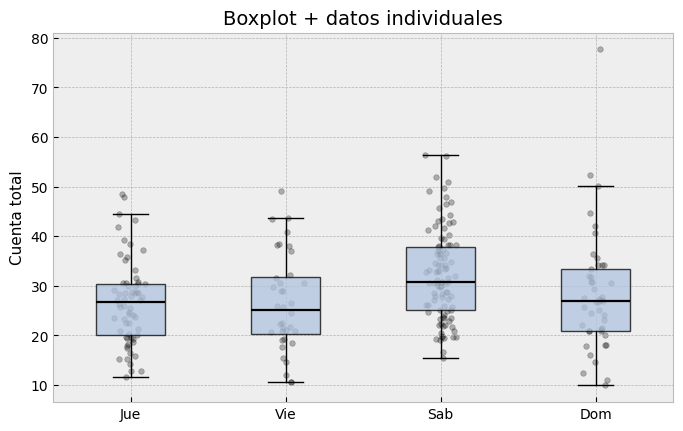

In [53]:
# Boxplot + puntos individuales — matplotlib
fig, ax = plt.subplots(figsize=(8, 4.8))
datos_por_dia = [propinas.loc[propinas["dia"] == dia, "cuenta_total"] for dia in dias]

ax.boxplot(datos_por_dia, positions=np.arange(len(dias)), widths=0.45, patch_artist=True,
           boxprops={"facecolor": "lightsteelblue", "alpha": 0.75},
           medianprops={"color": "black", "linewidth": 1.6},
           flierprops={"marker": ""})

for i, valores in enumerate(datos_por_dia):
    jitter = rng.normal(0, 0.045, size=len(valores))
    ax.scatter(np.full(len(valores), i) + jitter, valores, color="black", alpha=0.28, s=16)

ax.set_xticks(np.arange(len(dias)))
ax.set_xticklabels(dias)
ax.set_ylabel("Cuenta total")
ax.set_title("Boxplot + datos individuales")
plt.show()


## Referencias

1. [Quickstart tutorial-matplotlib](https://matplotlib.org/stable/tutorials/introductory/usage.html)